In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import src.figure as fi

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [2]:
fluorophores_18 = fl.construct_fluorophores('cy5', 18, 2)
fluorophore_system_18 = fl.FluorophoreSystem(fluorophores=fluorophores_18)

fluorophores_9 = fl.construct_fluorophores('cy5', 9, 2)
fluorophore_system_9 = fl.FluorophoreSystem(fluorophores=fluorophores_9)

fluorophores_6 = fl.construct_fluorophores('cy5', 6, 2)
fluorophore_system_6 = fl.FluorophoreSystem(fluorophores=fluorophores_6)

fluorophores_3 = fl.construct_fluorophores('cy5', 3, 2)
fluorophore_system_3 = fl.FluorophoreSystem(fluorophores=fluorophores_3)

fluorophore_ref = fl.construct_fluorophores('cy5', 0, 1)
fluorophore_system_ref = fl.FluorophoreSystem(fluorophores=fluorophore_ref)

In [3]:
transitions_18 = tr.load_transitions(fluorophore_system_18, 2.5, 640)
transition_set_18 = tr.TransitionSet(transitions_18, fluorophore_system_18)
transition_set_18 = transition_set_18.filter_by_abbreviation(remove_list=['OFRET', 'HFRET', 'CFRET', 'TFRET'])
transition_set_18.finalize()

transitions_9 = tr.load_transitions(fluorophore_system_9, 2.5, 640)
transition_set_9 = tr.TransitionSet(transitions_9, fluorophore_system_9)
transition_set_9 = transition_set_9.filter_by_abbreviation(remove_list=['OFRET', 'HFRET', 'CFRET', 'TFRET'])
transition_set_9.finalize()

transitions_6 = tr.load_transitions(fluorophore_system_6, 2.5, 640)
transition_set_6 = tr.TransitionSet(transitions_6, fluorophore_system_6)
transition_set_6 = transition_set_6.filter_by_abbreviation(remove_list=['OFRET','HFRET', 'CFRET', 'TFRET'])
transition_set_6.finalize()

transitions_3 = tr.load_transitions(fluorophore_system_3, 2.5, 640)
transition_set_3 = tr.TransitionSet(transitions_3, fluorophore_system_3)
transition_set_3 = transition_set_3.filter_by_abbreviation(remove_list=['OFRET','HFRET', 'CFRET', 'TFRET'])
transition_set_3.finalize()

transitions_3_trolox = tr.load_transitions(fluorophore_system_3, 2.5, 640)
transition_set_3_trolox = tr.TransitionSet(transitions_3_trolox, fluorophore_system_3)
transition_set_3_trolox = transition_set_3_trolox.filter_by_abbreviation(remove_list=['OFRET', 'HFRET', 'CFRET', 'TFRET', 'RED', 'OXI'])
transition_set_3_trolox.finalize()

transitions_ref = tr.load_transitions(fluorophore_system_ref, 2.5, 640)
transition_set_ref = tr.TransitionSet(transitions_ref, fluorophore_system_ref)
transition_set_ref.finalize()

In [4]:
simulation_18 = si.Simulation(transition_set_18)
simulation_18.run(size=int(1e7), end_time=300, seed=3)
print('round 1 finish')
simulation_9 = si.Simulation(transition_set_9)
simulation_9.run(size=int(1e7), end_time=300, seed=3)
print('round 2 finish')

simulation_6 = si.Simulation(transition_set_6)
simulation_6.run(size=int(1e7), end_time=300, seed=3)
print('round 3 finish')

simulation_3 = si.Simulation(transition_set_3)
simulation_3.run(size=int(1e7), end_time=300, seed=3)
print('round 4 finish')

# simulation_3_trolox = si.Simulation(transition_set_3_trolox)
# simulation_3_trolox.run(size=int(1e7), end_time=10, seed=3)
# print('round 5 finish')

simulation_ref = si.Simulation(transition_set_ref)
simulation_ref.run(size=int(1e7), end_time=300, seed=3)

round 1 finish
round 2 finish
round 3 finish
round 4 finish


In [5]:
emissions_18 = em.Emissions(simulation_18, photon_collection_rate=0.01, resample='1ms', emccd_gain=100, seed=100)

emissions_9 = em.Emissions(simulation_9, photon_collection_rate=0.01, resample='1ms', emccd_gain=100, seed=100)

emissions_6 = em.Emissions(simulation_6, photon_collection_rate=0.01, resample='1ms', emccd_gain=100, seed=100)

emissions_3 = em.Emissions(simulation_3, photon_collection_rate=0.01, resample='1ms', emccd_gain=100, seed=100)

# emissions_3_trolox = em.Emissions(simulation_3_trolox, photon_collection_rate=0.01, resample='1ms', emccd_gain=100, seed=100)

emissions_ref = em.Emissions(simulation_ref, photon_collection_rate=0.01, resample='1ms', emccd_gain=100, seed=100)

In [6]:
blinking_18 = bl.Blinking(emissions_18)

blinking_9 = bl.Blinking(emissions_9)

blinking_6 = bl.Blinking(emissions_6)

blinking_3 = bl.Blinking(emissions_3)

#blinking_3_trolox = bl.Blinking(emissions_3_trolox)

blinking_ref = bl.Blinking(emissions_ref)

In [7]:
fcs_ref = fc.FCS(emissions_ref).autocorrelate_time_points(exp_min=-10, exp_max=-1)

fcs_3 = fc.FCS(emissions_3).autocorrelate_time_points(exp_min=-10, exp_max=-1)

#fcs_3_trolox = fc.FCS(emissions_3_trolox).autocorrelate_time_points(exp_min=-10, exp_max=-1)

In [54]:
tcspc_ref = tc.TCSPC(transition_set_ref)
tcspc_ref.run(size=100000, seed=100)
tcspc_ref.get_observed_lifetimes()

tcspc_3 = tc.TCSPC(transition_set_3)
tcspc_3.run(size=100000, seed=100)
tcspc_3.get_observed_lifetimes()

tcspc_3_trolox = tc.TCSPC(transition_set_3_trolox)
tcspc_3_trolox.run(size=100000, seed=100)
tcspc_3_trolox.get_observed_lifetimes()

In [9]:
analysis_18 = st.Analysis(simulation_18)

analysis_9 = st.Analysis(simulation_9)

analysis_6 = st.Analysis(simulation_6)

analysis_3 = st.Analysis(simulation_3)

# Collection of all plots shown in 
Photoswitching fingerprint analysis bypasses the 10-nm resolution barrier
Dominic A. Helmerich, Gerti Beliu, Danush Taban, Mara Meub, Marcel Streit, Alexander Kuhlemann, Sören Doose & Markus Sauer 
# that are recreatable by simulation

## Figure 1 (except B, C, F)
irradiance: $5 \frac{kW}{cm^2}$ \
wavelength: $640 nm$ \
intensity threshold: $500 photons per frame$ \
binning: $5 ms$ \
images: $120.000$ \
total time: $600 s$ \
MEA: $100 mM$ \
MgCl2 for DNA origami: $50 mM$ 

### A
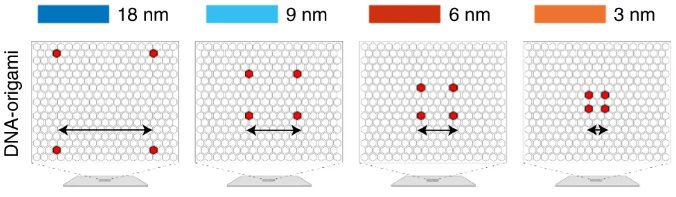

array([[<AxesSubplot:xlabel='x [nm]', ylabel='y [nm]'>]], dtype=object)

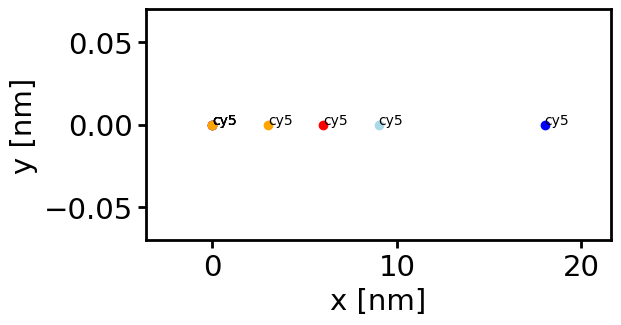

In [10]:
axes = fluorophore_system_18.plot(quadratic=False)
fluorophore_system_9.plot(axes=axes[0], color='lightblue', quadratic=False)
fluorophore_system_6.plot(axes=axes[0], color='red', quadratic=False)
fluorophore_system_3.plot(axes=axes[0], color='orange', quadratic=False)

### D
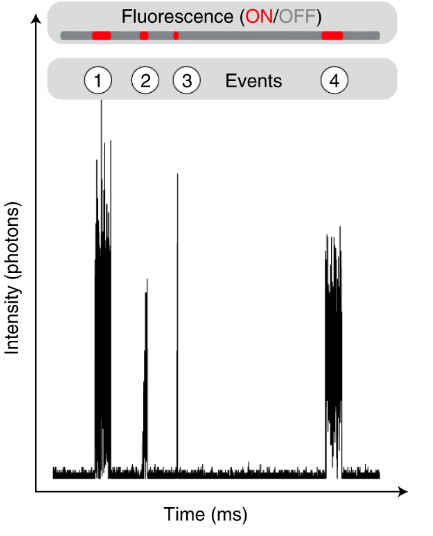

array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [ms]', ylabel='photon count'>]],
      dtype=object)

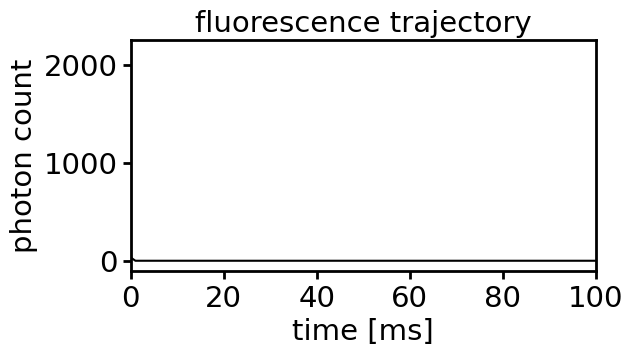

In [11]:
emissions_3.plot(mode='time_series', color='k', xlim=[0, 0.1], adjust_x=1000, xlabel='time [ms]')

### E
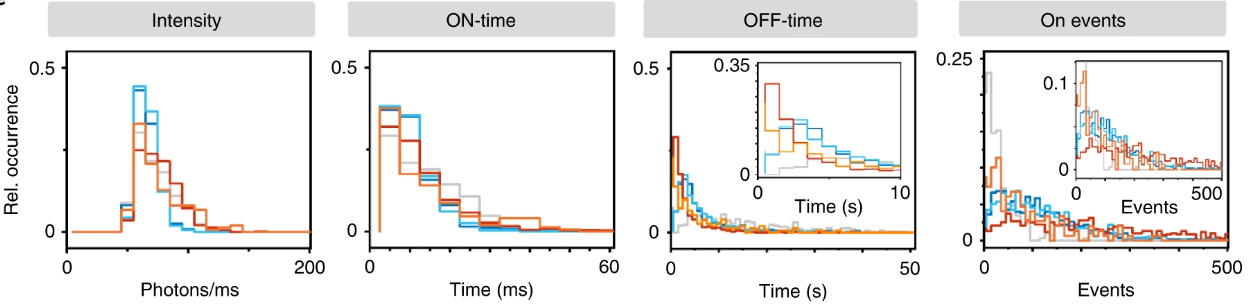 \
1 - considering ON-states; higher for 3, 6 nm \
2 - ON-times: similar \
3 - OFF-times: shorter the closer the fluorophores \
4 - ON events: broad distr. -> often less than 4 fluorophores localized 


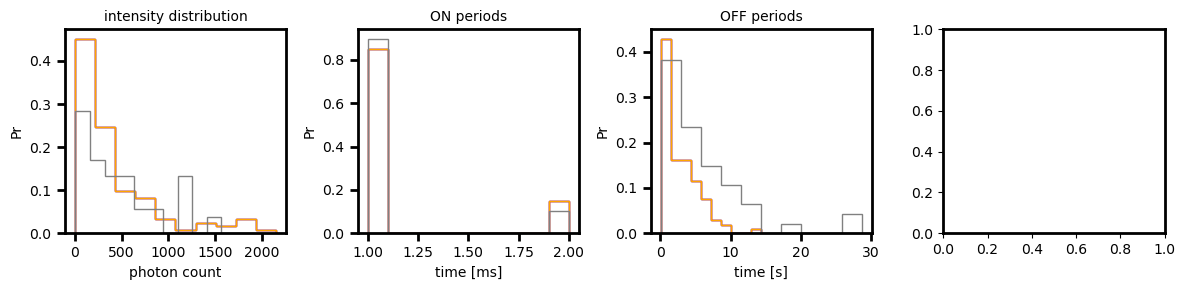

In [12]:
emission_plot_param = {'mode': 'histogram',
                       'histtype': 'step',
                       'fontsize': 10,
                       'density': False}
axes = emissions_18.plot(ncols=4, fig_width=12, fig_height=3, **emission_plot_param)
emissions_9.plot(axes=axes[0, 0], color='lightblue', **emission_plot_param)
emissions_6.plot(axes=axes[0, 0], color='r', **emission_plot_param)
emissions_3.plot(axes=axes[0, 0], color='orange', **emission_plot_param)
emissions_ref.plot(axes=axes[0, 0], color='grey', **emission_plot_param)
blinking_on_plot_param = {'mode': 'on_histogram',
                          'histtype': 'step',
                          'fontsize': 10,
                          'display_mean': False,
                          'density': False,
                          'as_time': 'ms'}
blinking_18.plot(axes=axes[0, 1], **blinking_on_plot_param)
blinking_9.plot(axes=axes[0, 1], color='lightblue', **blinking_on_plot_param)
blinking_6.plot(axes=axes[0, 1], color='r', **blinking_on_plot_param)
blinking_3.plot(axes=axes[0, 1], color='orange', **blinking_on_plot_param)
blinking_ref.plot(axes=axes[0, 1], color='grey', **blinking_on_plot_param)
blinking_off_plot_param = {'mode': 'off_histogram',
                           'histtype': 'step',
                           'fontsize': 10,
                           'display_mean': False,
                           'density': False,
                           'as_time': 's'}
blinking_18.plot(axes=axes[0, 2], **blinking_off_plot_param)
blinking_9.plot(axes=axes[0, 2], color='lightblue', **blinking_off_plot_param)
blinking_6.plot(axes=axes[0, 2], color='r', **blinking_off_plot_param)
blinking_3.plot(axes=axes[0, 2], color='orange', **blinking_off_plot_param)
blinking_ref.plot(axes=axes[0, 2], color='grey', **blinking_off_plot_param)


axes[0, 0].get_figure().tight_layout()

### G
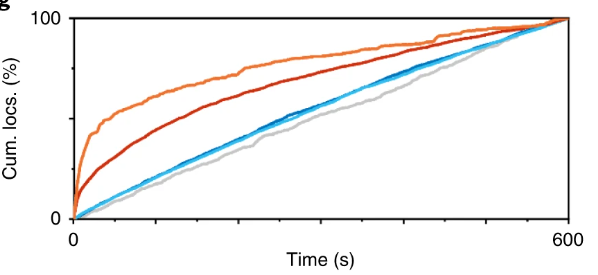 \
linear increase for ref, 18, 9 nm -> homogeneous blinking until photobleaching \
3, 6 nm -> faster blinking, photobleaching

array([[<AxesSubplot:title={'center':'cum. events'}, xlabel='time [s]', ylabel='%'>]],
      dtype=object)

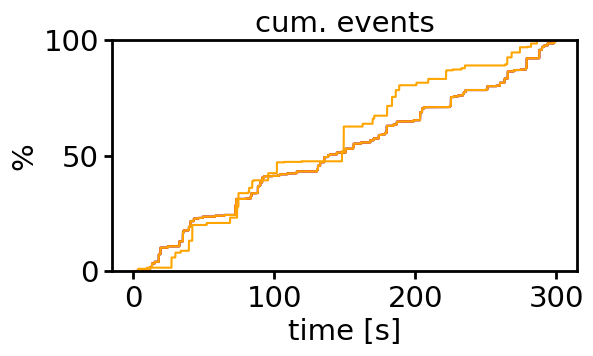

In [13]:
axes = emissions_18.plot('cum_events')
emissions_9.plot('cum_events', axes=axes[0], color='lightblue')
emissions_6.plot('cum_events', axes=axes[0], color='r')
emissions_3.plot('cum_events', axes=axes[0], color='orange')
emissions_ref.plot('cum_events', axes=axes[0], color='orange')

### H
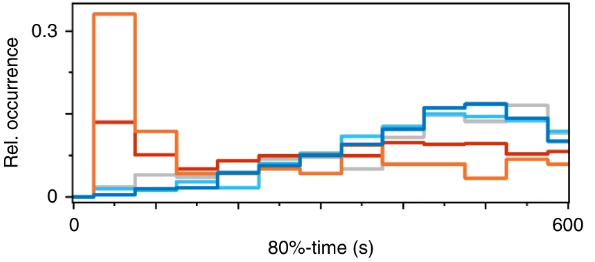 \
majority of 3, 6 nm show fast blinking \
time after which 80% of locs appeared \
photobleaching

In [2]:
collector = []
for event_time_series in event_time_series_collection:
    cum_events = event_time_series.cumsum()
    cum_events = cum_events / cum_events.max() * 100
    eighty_percent_time = cum_events[cum_events < 80].index 
    collector.append(eighty_percent_time)
data = collector
fi.universal_figure(data, type_='hist', xlabel='80%-time', histtype='step')

NameError: name 'event_time_series_collection' is not defined

---

## Figure 2 (except K)

### A - H
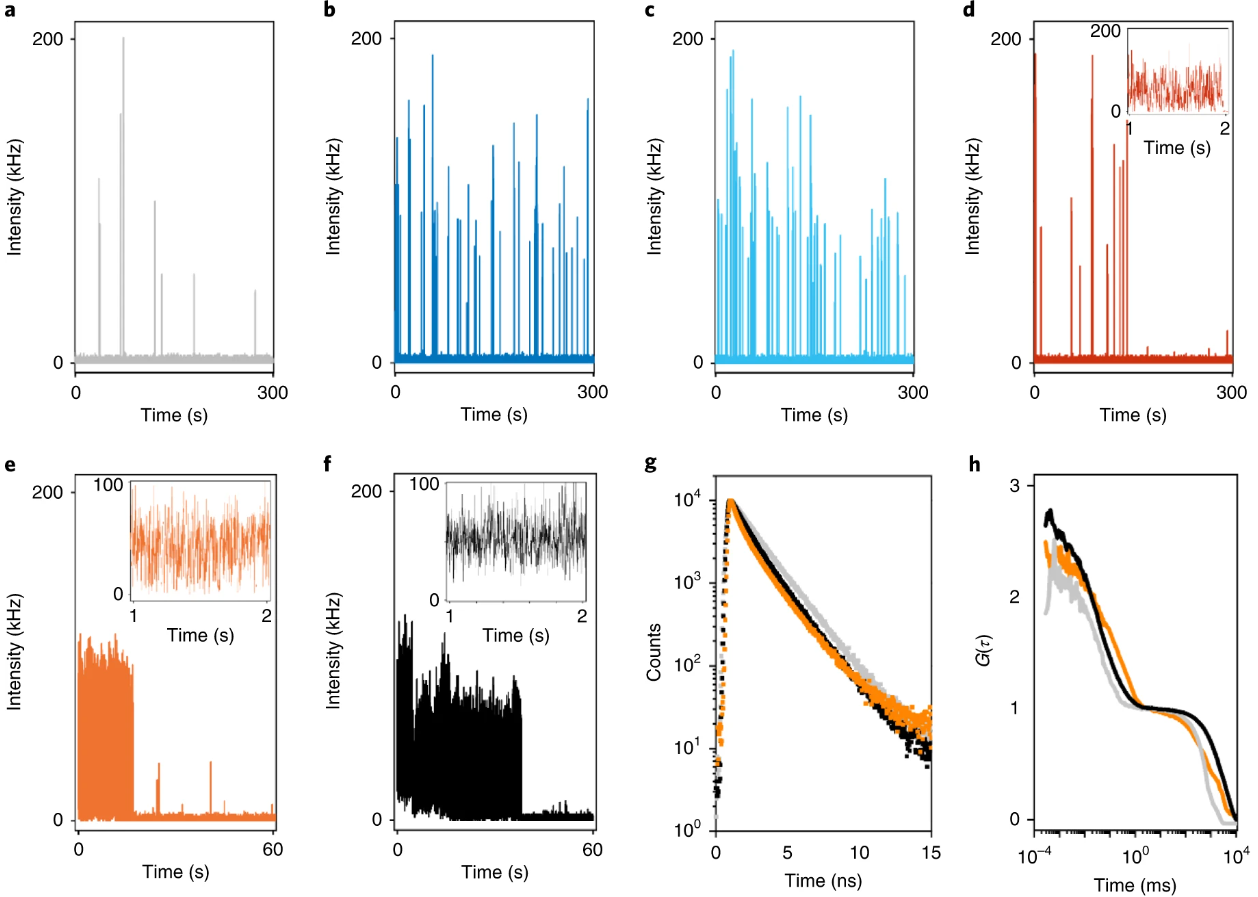 \
irradiance: $2.5 \frac{kW}{cm^2}$ \
binning: $1 ms$ \
wavelength: $640 nm$ \
time resolution: $25 ps$ \
A - ms ON-times, s OFF-times \
B - more switching events per time than ref (4 fluorophores), similar intensities \
C - at beginning of irradiation faster photoswitching indicated \
D, E - very fast photoswitching, OFF-times much shorter (ms) \
F - higher intensity levels than 3 nm dSTORM but else similar (indicating 3 nm dstorm mostly in ON state) \
G - TCSPC? ref: monoexponential, mean 1.8 ns; 3nm trolox multiexponential with 600 ps component due to cis/trans energy transfer; 3 nm  photoswitch multiexponential with 400 ps component due to on/off energy transfer; Note: multiexponential also possible due to different amount of available acceptors in these moments \
H - normalized to value corresponding of lag time of $1 ms$; only first seconds correlated; 3ms trolox dominated by trans/cis (and to triplet?!); 3ms photosw small on/off component at few hundred ms

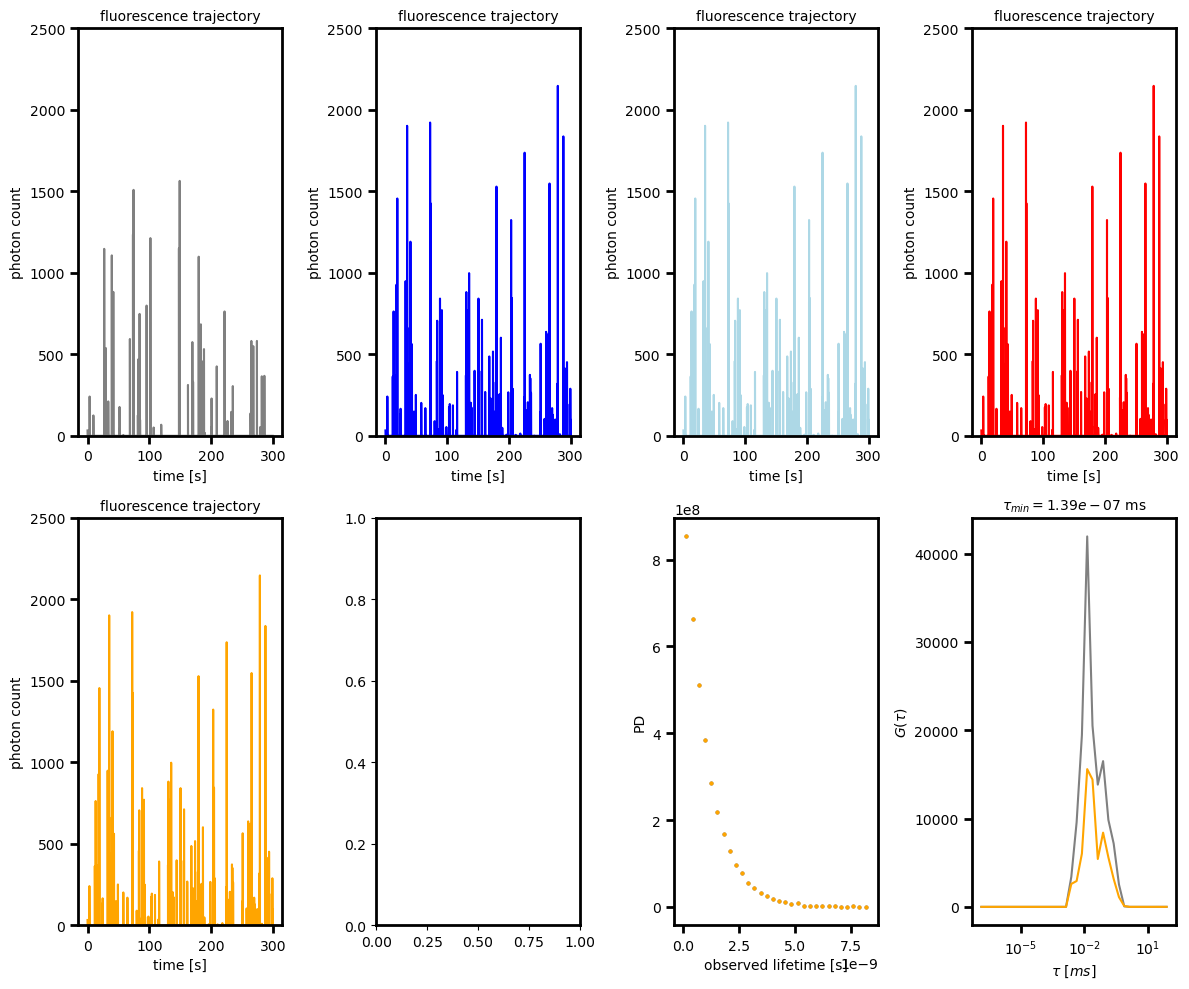

In [55]:
upper_bound_intensity = 2500
axes = emissions_ref.plot('time_series', ncols=4, nrows=2, fig_height=10, fig_width=12, color='grey', 
                          fontsize=10, ylim=[0, upper_bound_intensity])
emissions_18.plot('time_series', axes=axes[0, 1], fontsize=10, ylim=[0, upper_bound_intensity])
emissions_9.plot('time_series', axes=axes[0, 2], color='lightblue', fontsize=10, ylim=[0, upper_bound_intensity])
emissions_6.plot('time_series', axes=axes[0, 3], color='r', fontsize=10, ylim=[0, upper_bound_intensity])
emissions_3.plot('time_series', axes=axes[1, 0], color='orange', fontsize=10, ylim=[0, upper_bound_intensity])
#emissions_3_trolox.plot('time_series', axes=axes[1, 1], color='k', fontsize=10, ylim=[0, upper_bound_intensity])

tcspc_ref.plot(mode='simulation', color='grey', axes=axes[1, 2], fontsize=10, bins=30, histtype='dot', title='')
tcspc_3.plot(mode='simulation', color='orange', axes=axes[1, 2], fontsize=10, bins=30, histtype='dot', title='')
#tcspc_3_trolox.plot(mode='simulation', color='k', axes=axes[1, 2], fontsize=10)

fcs_ref.plot(axes=axes[1, 3], color='grey', fontsize=10, unit='ms')
fcs_3.plot(axes=axes[1, 3], color='orange', fontsize=10, unit='ms')
#fcs_3_trolox.plot(axes=axes[1, 3], color='k', fontsize=10)

axes[0, 0].get_figure().tight_layout()

### I
#### Note: the recreated plot displays true simulated lifetimes!
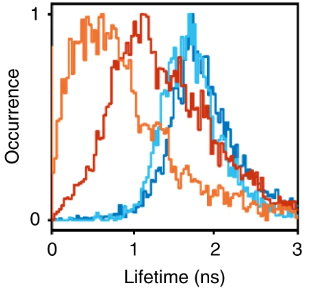 \
Fluorescence lifetime decreases with decraesing interfluorophore distance

In [ ]:
collector = []
for analysis in analysis_collection:
    mean_S1_lifetime = analysis.mean_lifetimes[1] 
    collector.append(mean_S1_lifetime)
data = collector
axes = fi.universal_figure(data, type_='hist', xlabel='lifetime', histtype='step', color='lightblue')
fi.universal_figure(data, type_='hist', xlabel='lifetime', histtype='step', axes=axes[0], color='lightblue')
fi.universal_figure(data, type_='hist', xlabel='lifetime', histtype='step', axes=axes[0], color='red')
fi.universal_figure(data, type_='hist', xlabel='lifetime', histtype='step', axes=axes[0], color='orange')

### J
#### Note: the recreated plot displays true simulated lifetime distributions!
#### Note: the 3-configuration is a equilateral triangle!
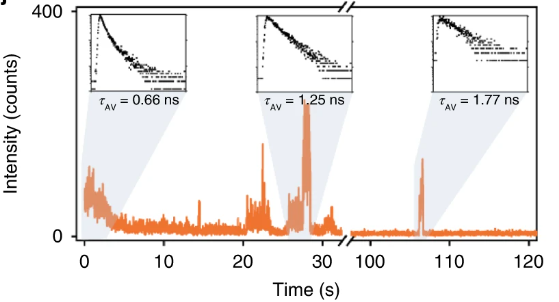 \
Fluorescence lifetime increases with increasing photobleaching

In [19]:
fluorophores_3_4 = fl.construct_fluorophores('cy5', 3, 4)
fluorophore_system_3_4 = fl.FluorophoreSystem(fluorophores=fluorophores_3_4)

fluorophores_3_3 = fl.construct_fluorophores('cy5', 3, 3)
fluorophore_system_3_3 = fl.FluorophoreSystem(fluorophores=fluorophores_3_3)

fluorophores_3_2 = fl.construct_fluorophores('cy5', 3, 2)
fluorophore_system_3_2 = fl.FluorophoreSystem(fluorophores=fluorophores_3_2)

fluorophores_3_1 = fl.construct_fluorophores('cy5', 0, 1)
fluorophore_system_3_1 = fl.FluorophoreSystem(fluorophores=fluorophores_3_1)

transitions_3_4 = tr.load_transitions(fluorophore_system_3_4, 2.5, 640)
transition_set_3_4 = tr.TransitionSet(transitions_3_4, fluorophore_system_3_4)
transition_set_3_4.finalize()

transitions_3_3 = tr.load_transitions(fluorophore_system_3_3, 2.5, 640)
transition_set_3_3 = tr.TransitionSet(transitions_3_3, fluorophore_system_3_3)
transition_set_3_3.finalize()

transitions_3_2 = tr.load_transitions(fluorophore_system_3_2, 2.5, 640)
transition_set_3_2 = tr.TransitionSet(transitions_3_2, fluorophore_system_3_2)
transition_set_3_2.finalize()

transitions_3_1 = tr.load_transitions(fluorophore_system_3_1, 2.5, 640)
transition_set_3_1 = tr.TransitionSet(transitions_3_1, fluorophore_system_3_1)
transition_set_3_1.finalize()

simulation_3_4 = si.Simulation(transition_set_3_4)
simulation_3_4.run(size=int(1e5), end_time=None, seed=3)

simulation_3_3 = si.Simulation(transition_set_3_3)
simulation_3_3.run(size=int(1e5), end_time=None, seed=3)

simulation_3_2 = si.Simulation(transition_set_3_2)
simulation_3_2.run(size=int(1e5), end_time=None, seed=3)

simulation_3_1 = si.Simulation(transition_set_3_1)
simulation_3_1.run(size=int(1e5), end_time=None, seed=3)

analysis_3_4 = st.Analysis(simulation_3_4)
mean_3_4 = analysis_3_4.mean_lifetimes[1]

analysis_3_3 = st.Analysis(simulation_3_3)
mean_3_3 = analysis_3_3.mean_lifetimes[1]

analysis_3_2 = st.Analysis(simulation_3_2)
mean_3_2 = analysis_3_2.mean_lifetimes[1]

analysis_3_1 = st.Analysis(simulation_3_1)
mean_3_1 = analysis_3_1.mean_lifetimes[1]

array([[<Axes: xlabel='lifetime [s]', ylabel='PD'>]], dtype=object)

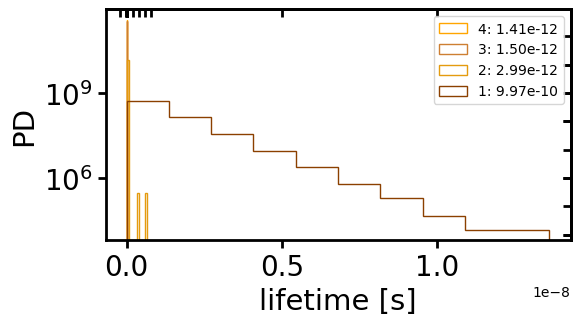

In [67]:
axes = analysis_3_4.plot('lifetime_distributions', exclude=[0, 3, 5, 6, 4], color='orange', label=f'4: {mean_3_4:.2e}',
                         legend=True, histtype='step')
analysis_3_3.plot('lifetime_distributions', exclude=[0, 3, 5, 6, 4], color='#CD7F32', label=f'3: {mean_3_3:.2e}', axes=axes[0], histtype='step')
analysis_3_2.plot('lifetime_distributions', exclude=[0, 3, 5, 6, 4],color='#E49B0F', label=f'2: {mean_3_2:.2e}', axes=axes[0], histtype='step')
analysis_3_1.plot('lifetime_distributions', exclude=[0, 3, 5, 6, 4],color='#8B4000', label=f'1: {mean_3_1:.2e}', axes=axes[0], histtype='step')

## Supplementary

### S 6-10 Antibunching
to get number of fluorophores \
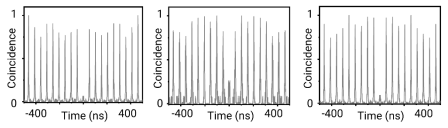 \
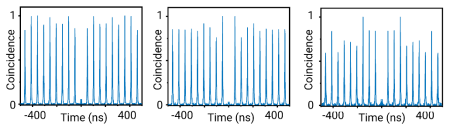 \
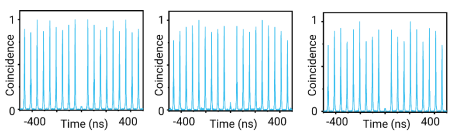 \
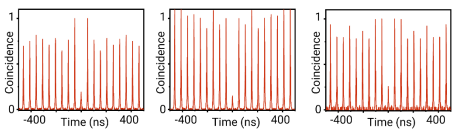 \
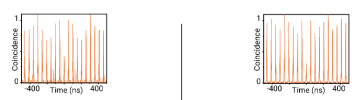 \
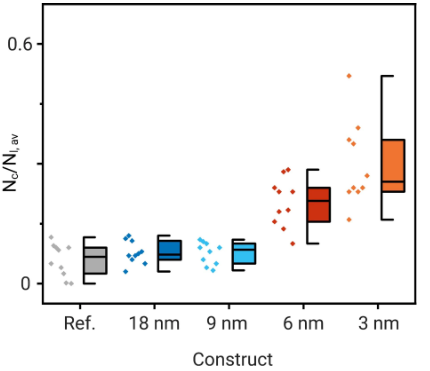 \
higher ratios for 3, 6 nm indicate ON state repopulation and are in accordance to the higher intensities per ON-frame \
Simulation difficulties of pulsed case see ppt

### Extended data
or supplementary (depending on version) \
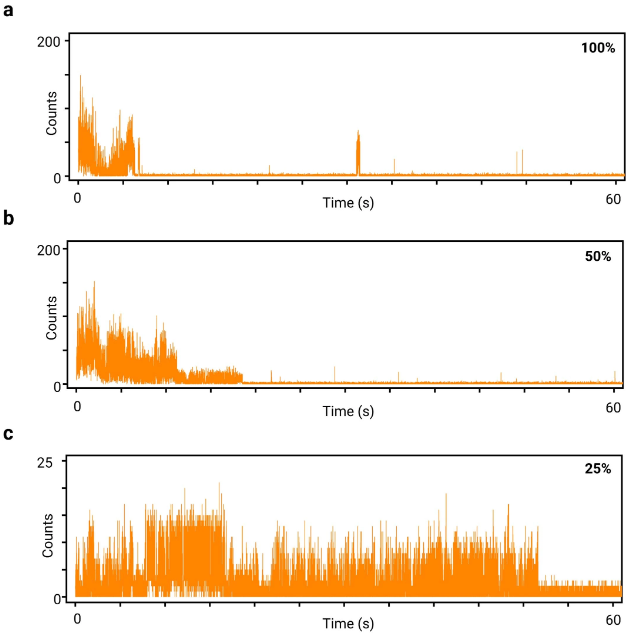 \
Reduction of irradiance slows down blinking kinetics and decreases fluorescence intensity